In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
import re
import os

sns.set_style("whitegrid")
os.makedirs("results", exist_ok=True)

print("Libraries loaded.")

Libraries loaded.


In [2]:
df = pd.read_csv("../data/clinvar_result.txt", sep="\t")

cols_to_remove = [
    "Somatic clinical impact",
    "Somatic clinical impact date last evaluated",
    "Somatic clinical impact review status",
    "Oncogenicity classification",
    "Oncogenicity date last evaluated",
    "Oncogenicity review status",
    "Unnamed: 24",
]
df = df.drop(columns=cols_to_remove)

print(f"Loaded {len(df)} OTOF variants from ClinVar.")

Loaded 2432 OTOF variants from ClinVar.


In [3]:
def extract_aa_position(name):
    if pd.isna(name):
        return np.nan
    # Look for patterns like "p.Arg963Ter" or "p.Met1858Val" or "p.Gly783AlafsTer17"
    match = re.search(r"p\.[A-Z][a-z]{2}(\d+)", str(name))
    if match:
        return int(match.group(1))
    return np.nan

df["aa_position"] = df["Name"].apply(extract_aa_position)

# How many variants have an extractable amino acid position?
mapped = df["aa_position"].notna().sum()
print(f"Variants with extractable amino acid position: {mapped} / {len(df)}")
print(f"\nRange of positions: {int(df['aa_position'].min())} to {int(df['aa_position'].max())}")

Variants with extractable amino acid position: 1600 / 2432

Range of positions: 2 to 1997


In [4]:
# Otoferlin protein domains (UniProt P52787, canonical isoform, 1997 aa)
# Domain boundaries from UniProt + literature on C2 domain architecture
PROTEIN_LENGTH = 1997

domains = [
    {"name": "C2A", "start": 1,    "end": 122,  "color": "#4C72B0"},
    {"name": "C2B", "start": 360,  "end": 480,  "color": "#55A868"},
    {"name": "C2C", "start": 481,  "end": 596,  "color": "#C44E52"},
    {"name": "C2D", "start": 940,  "end": 1054, "color": "#8172B2"},
    {"name": "C2E", "start": 1158, "end": 1273, "color": "#CCB974"},
    {"name": "C2F", "start": 1481, "end": 1597, "color": "#64B5CD"},
    {"name": "TM",  "start": 1942, "end": 1973, "color": "#777777"},
]

# Assign each variant to its domain (or "Linker" if outside)
def assign_domain(pos):
    if pd.isna(pos):
        return None
    for d in domains:
        if d["start"] <= pos <= d["end"]:
            return d["name"]
    return "Linker"

df["domain"] = df["aa_position"].apply(assign_domain)

# Count variants per domain
domain_counts = df["domain"].value_counts()
print("Variants per domain:")
print(domain_counts)

Variants per domain:
domain
Linker    1020
C2E        103
C2C         99
C2A         92
C2D         88
C2B         88
C2F         85
TM          25
Name: count, dtype: int64


In [5]:
pathogenic_classes = ["Pathogenic", "Likely pathogenic", "Pathogenic/Likely pathogenic"]
benign_classes = ["Benign", "Likely benign", "Benign/Likely benign"]
vus_classes = ["Uncertain significance", "Conflicting classifications of pathogenicity"]

def simplify_classification(cls):
    if cls in pathogenic_classes:
        return "Pathogenic"
    if cls in benign_classes:
        return "Benign"
    if cls in vus_classes:
        return "Uncertain"
    return "Other"

df["simplified_class"] = df["Germline classification"].apply(simplify_classification)

# Crosstab domain vs simplified class
domain_class_table = pd.crosstab(df["domain"], df["simplified_class"])
print("Variants by domain and classification:")
print(domain_class_table)

Variants by domain and classification:
simplified_class  Benign  Other  Pathogenic  Uncertain
domain                                                
C2A                   42      0           8         42
C2B                   37      3          20         28
C2C                   46      5          18         30
C2D                   38      0          18         32
C2E                   49      0          15         39
C2F                   34      1          15         35
Linker               419     17         158        426
TM                    13      0           3          9


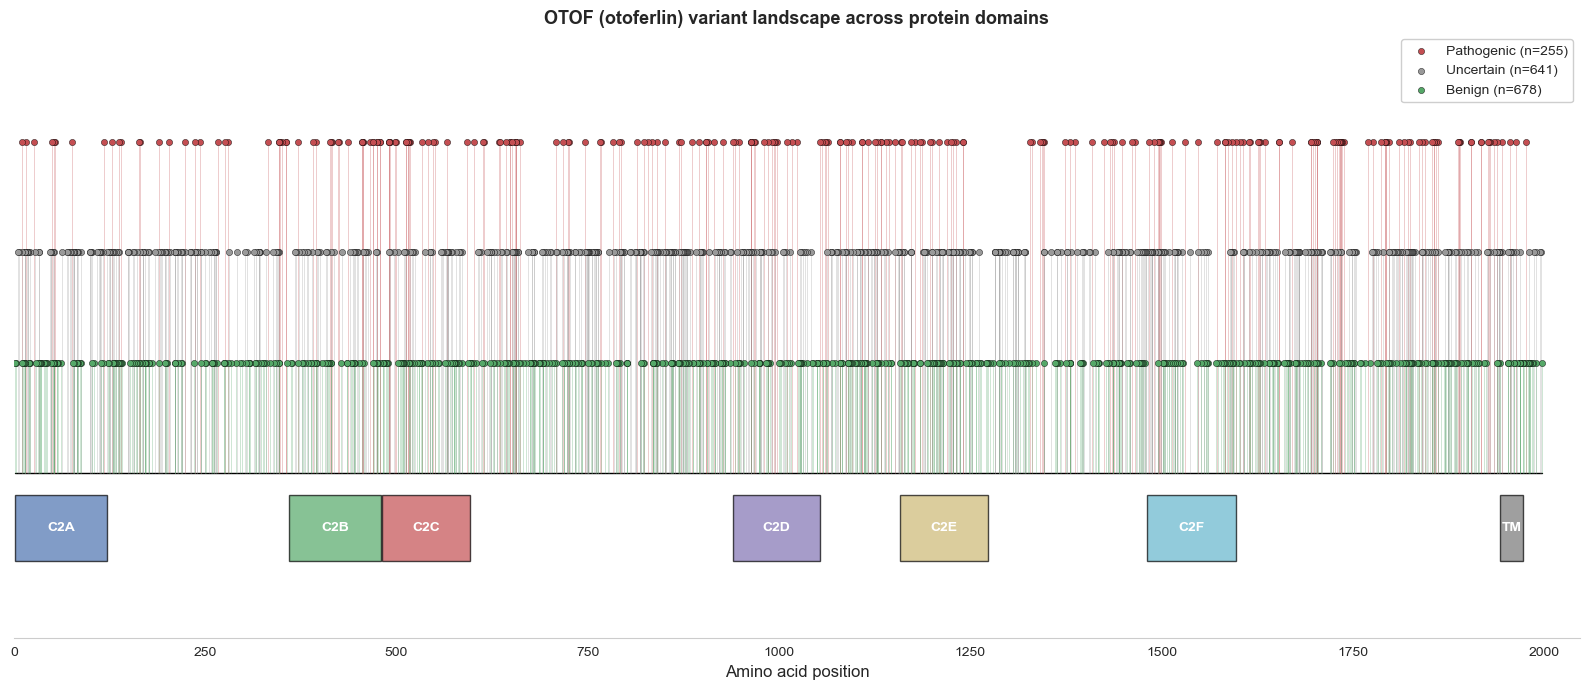

In [6]:
# Filter to variants with valid position and simplified class
plot_df = df.dropna(subset=["aa_position"]).copy()
plot_df = plot_df[plot_df["simplified_class"].isin(["Pathogenic", "Benign", "Uncertain"])]

# Color map
class_colors = {
    "Pathogenic": "#C44E52",
    "Benign": "#55A868",
    "Uncertain": "#999999",
}

# Set up figure
fig, ax = plt.subplots(figsize=(16, 7))

# Plot domains as colored rectangles at the bottom
domain_y = -0.8
domain_height = 0.6
for d in domains:
    rect = patches.Rectangle(
        (d["start"], domain_y), d["end"] - d["start"], domain_height,
        linewidth=1, edgecolor="black", facecolor=d["color"], alpha=0.7
    )
    ax.add_patch(rect)
    # Label inside the domain
    center = (d["start"] + d["end"]) / 2
    ax.text(center, domain_y + domain_height / 2, d["name"],
            ha="center", va="center", fontsize=10, fontweight="bold", color="white")

# Backbone line (the protein)
ax.plot([1, PROTEIN_LENGTH], [0, 0], color="black", linewidth=1, zorder=1)

# Plot variants as lollipops
# Stack variants by class: pathogenic top, uncertain middle, benign bottom
class_order = ["Pathogenic", "Uncertain", "Benign"]
class_y_offset = {"Pathogenic": 3, "Uncertain": 2, "Benign": 1}

for cls in class_order:
    subset = plot_df[plot_df["simplified_class"] == cls]
    positions = subset["aa_position"].values
    y_value = class_y_offset[cls]
    # Stem
    for pos in positions:
        ax.plot([pos, pos], [0, y_value], color=class_colors[cls], linewidth=0.4, alpha=0.5, zorder=2)
    # Marker (lollipop head)
    ax.scatter(positions, [y_value] * len(positions),
               s=20, color=class_colors[cls], edgecolor="black",
               linewidth=0.3, zorder=3, label=f"{cls} (n={len(positions)})")

# Axes setup
ax.set_xlim(0, PROTEIN_LENGTH + 50)
ax.set_ylim(-1.5, 4)
ax.set_xlabel("Amino acid position", fontsize=12)
ax.set_yticks([])
ax.set_title("OTOF (otoferlin) variant landscape across protein domains", fontsize=13, fontweight="bold")
ax.legend(loc="upper right", fontsize=10, framealpha=0.95)
ax.grid(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

plt.tight_layout()
plt.savefig("../results/otof_lollipop_plot.png", dpi=300, bbox_inches="tight")
plt.show()

In [7]:
# Pathogenic density per domain (P/LP per aa)
print("Pathogenic variant density per domain:")
print("=" * 60)

for d in domains:
    domain_name = d["name"]
    domain_length = d["end"] - d["start"] + 1
    n_pathogenic = len(plot_df[(plot_df["domain"] == domain_name) & (plot_df["simplified_class"] == "Pathogenic")])
    density = n_pathogenic / domain_length
    print(f"  {domain_name:6s} ({domain_length:4d} aa): {n_pathogenic:3d} pathogenic --> density = {density:.4f} per aa")

# Linker regions (everything outside domains)
linker_pathogenic = len(plot_df[(plot_df["domain"] == "Linker") & (plot_df["simplified_class"] == "Pathogenic")])
total_domain_aa = sum(d["end"] - d["start"] + 1 for d in domains)
linker_length = PROTEIN_LENGTH - total_domain_aa
linker_density = linker_pathogenic / linker_length
print(f"\n  {'Linker':6s} ({linker_length:4d} aa): {linker_pathogenic:3d} pathogenic --> density = {linker_density:.4f} per aa")

Pathogenic variant density per domain:
  C2A    ( 122 aa):   8 pathogenic --> density = 0.0656 per aa
  C2B    ( 121 aa):  20 pathogenic --> density = 0.1653 per aa
  C2C    ( 116 aa):  18 pathogenic --> density = 0.1552 per aa
  C2D    ( 115 aa):  18 pathogenic --> density = 0.1565 per aa
  C2E    ( 116 aa):  15 pathogenic --> density = 0.1293 per aa
  C2F    ( 117 aa):  15 pathogenic --> density = 0.1282 per aa
  TM     (  32 aa):   3 pathogenic --> density = 0.0938 per aa

  Linker (1258 aa): 158 pathogenic --> density = 0.1256 per aa


## Statistical Analysis — Domain-Level Pathogenic Variant Density

We test whether the observed distribution of pathogenic variants across
C2 domains deviates significantly from the null expectation of uniform
distribution proportional to domain length, using two complementary approaches:
1. Chi-square goodness-of-fit test against the length-proportional null
2. Permutation test (n=10,000) without parametric assumptions

In [8]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# Domain definitions (UniProt Q9HC10, 1997 aa)
domains = {
    "C2A": 122, "C2B": 121, "C2C": 116,
    "C2D": 115, "C2E": 116, "C2F": 117, "TM": 32,
}

# Observed P/LP counts per domain (from your domain mapping analysis)
plp_counts = {
    "C2A": 8, "C2B": 20, "C2C": 18,
    "C2D": 18, "C2E": 15, "C2F": 15, "TM": 3,
}

total_plp    = sum(plp_counts.values())
total_length = sum(domains.values())

# Expected under length-proportional null
expected = {d: (domains[d] / total_length) * total_plp for d in domains}

print(f"Total P/LP in named domains : {total_plp}")
print(f"Total named domain length   : {total_length} aa\n")
print(f"{'Domain':6s} {'Length':>7s} {'Observed':>9s} {'Expected':>9s}")
print("-" * 35)
for d in domains:
    print(f"{d:6s} {domains[d]:>7d} {plp_counts[d]:>9d} {expected[d]:>9.1f}")

Total P/LP in named domains : 97
Total named domain length   : 739 aa

Domain  Length  Observed  Expected
-----------------------------------
C2A        122         8      16.0
C2B        121        20      15.9
C2C        116        18      15.2
C2D        115        18      15.1
C2E        116        15      15.2
C2F        117        15      15.4
TM          32         3       4.2


In [9]:
# Chi-square goodness-of-fit
obs_arr = np.array([plp_counts[d] for d in domains])
exp_arr = np.array([expected[d]   for d in domains])

chi2, pval_chi2 = stats.chisquare(f_obs=obs_arr, f_exp=exp_arr)

print("=" * 55)
print("Chi-square goodness-of-fit")
print(f"  Chi2 = {chi2:.3f}  |  df = {len(domains)-1}  |  p = {pval_chi2:.4f}")
if pval_chi2 < 0.05:
    print("  SIGNIFICANT: domain enrichment is non-random")
else:
    print("  Not significant at alpha = 0.05")
print("=" * 55)

Chi-square goodness-of-fit
  Chi2 = 6.497  |  df = 6  |  p = 0.3699
  Not significant at alpha = 0.05


In [10]:
# Permutation test (n=10,000)
np.random.seed(42)
N_PERM = 10_000

# Build residue-label array for all named-domain residues
residue_labels = np.repeat(list(domains.keys()),
                           list(domains.values()))

print(f"Permuting {total_plp} P/LP variants over "
      f"{total_length} residues × {N_PERM:,} permutations...")

perm_densities = {d: np.empty(N_PERM) for d in domains}
domain_lengths = np.array([domains[d] for d in domains])
domain_names   = np.array(list(domains.keys()))

for i in range(N_PERM):
    idx = np.random.choice(total_length, size=total_plp, replace=False)
    sampled = residue_labels[idx]
    for j, d in enumerate(domains):
        perm_densities[d][i] = np.sum(sampled == d) / domains[d]

# Results table
print(f"\n{'Domain':6s} {'Length':>7s} {'P/LP':>5s} "
      f"{'Obs dens':>10s} {'Null mean':>10s} {'p-value':>10s} {'Sig':>5s}")
print("-" * 60)

results_rows = []
for d in domains:
    obs_d  = plp_counts[d] / domains[d]
    pval   = float(np.mean(perm_densities[d] >= obs_d))
    sig    = ("***" if pval < 0.001 else
              "**"  if pval < 0.01  else
              "*"   if pval < 0.05  else "n.s.")
    print(f"{d:6s} {domains[d]:>7d} {plp_counts[d]:>5d} "
          f"{obs_d:>10.4f} {perm_densities[d].mean():>10.4f} "
          f"{pval:>10.4f} {sig:>5s}")
    results_rows.append({
        "Domain": d, "Length_aa": domains[d],
        "PLP_count": plp_counts[d], "Obs_density": round(obs_d, 4),
        "Null_mean": round(perm_densities[d].mean(), 4),
        "Null_SD": round(perm_densities[d].std(), 4),
        "p_value": round(pval, 4) if pval > 0 else f"<{1/N_PERM:.4f}",
        "Significance": sig,
    })

import pandas as pd
results_df = pd.DataFrame(results_rows)
results_df.to_csv("../results/domain_permutation_test.csv", index=False)
print("\nSaved: results/domain_permutation_test.csv")
print(f"\nChi-square: chi2={chi2:.3f}, df={len(domains)-1}, p={pval_chi2:.4f}")

Permuting 97 P/LP variants over 739 residues × 10,000 permutations...



Domain  Length  P/LP   Obs dens  Null mean    p-value   Sig
------------------------------------------------------------
C2A        122     8     0.0656     0.1312     0.9955  n.s.
C2B        121    20     0.1653     0.1312     0.1420  n.s.
C2C        116    18     0.1552     0.1315     0.2490  n.s.
C2D        115    18     0.1565     0.1310     0.2276  n.s.
C2E        116    15     0.1293     0.1310     0.5726  n.s.
C2F        117    15     0.1282     0.1315     0.5968  n.s.
TM          32     3     0.0938     0.1316     0.8212  n.s.

Saved: results/domain_permutation_test.csv

Chi-square: chi2=6.497, df=6, p=0.3699


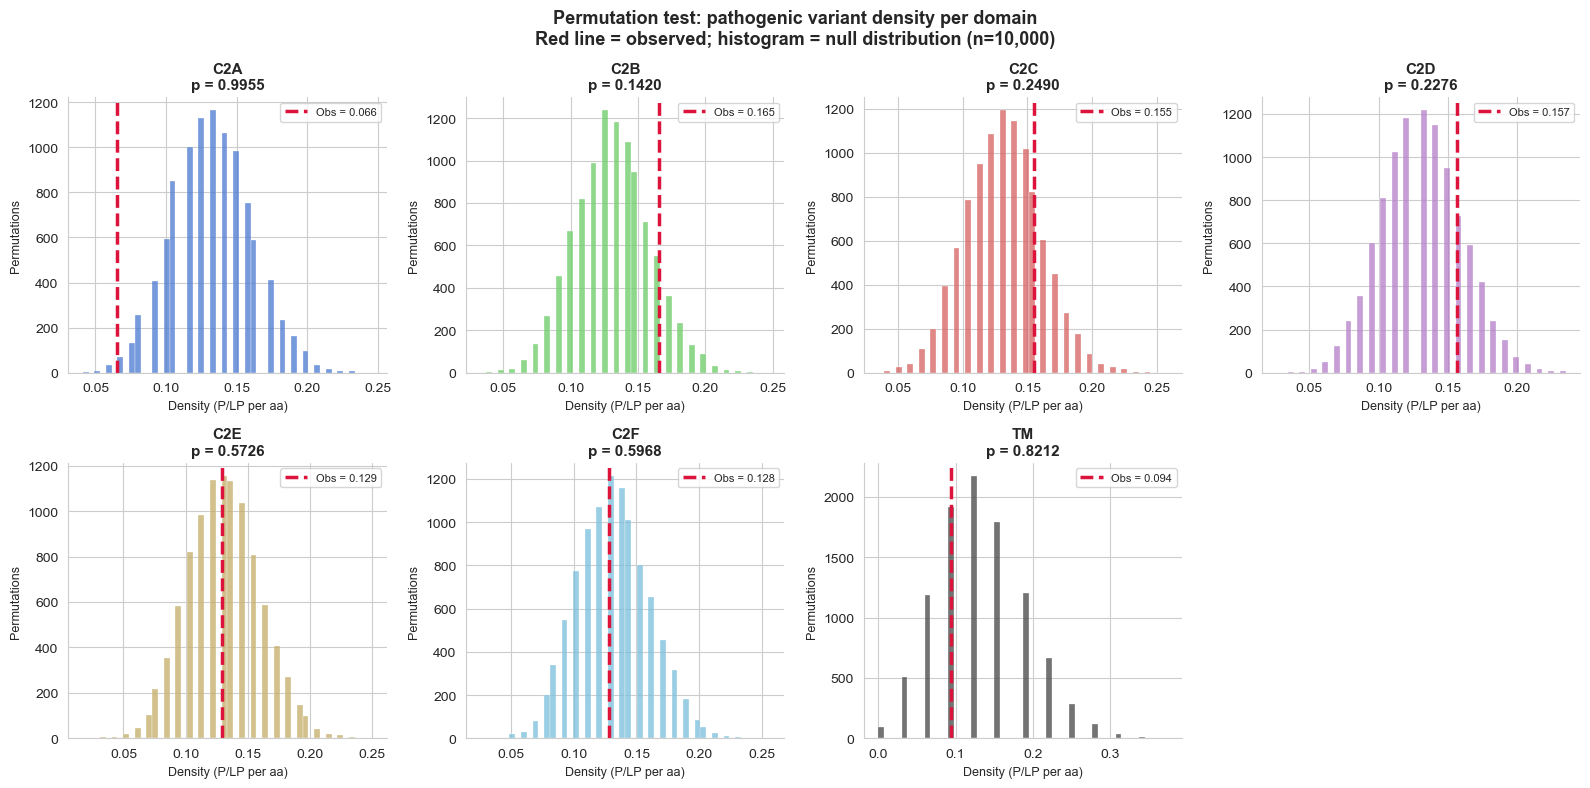

Saved: results/domain_permutation_test.png


In [11]:
# Figure: permutation distributions
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

domain_colors = {
    "C2A": "#4878d0", "C2B": "#6acc65", "C2C": "#d65f5f",
    "C2D": "#b47cc7", "C2E": "#c4ad66", "C2F": "#77bedb", "TM": "#444444"
}

for i, d in enumerate(domains):
    ax    = axes[i]
    perm  = perm_densities[d]
    obs_d = plp_counts[d] / domains[d]
    pval  = float(np.mean(perm >= obs_d))

    ax.hist(perm, bins=50, color=domain_colors[d],
            alpha=0.75, edgecolor="white", linewidth=0.3)
    ax.axvline(obs_d, color="crimson", linewidth=2.5, linestyle="--",
               label=f"Obs = {obs_d:.3f}")
    pval_label = f"p = {pval:.4f}" if pval > 0 else f"p < {1/N_PERM:.4f}"
    ax.set_title(f"{d}\n{pval_label}", fontsize=11, fontweight="bold")
    ax.set_xlabel("Density (P/LP per aa)", fontsize=9)
    ax.set_ylabel("Permutations", fontsize=9)
    ax.legend(fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)

axes[7].set_visible(False)

fig.suptitle(
    "Permutation test: pathogenic variant density per domain\n"
    "Red line = observed; histogram = null distribution (n=10,000)",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.savefig("../results/domain_permutation_test.png",
            dpi=300, bbox_inches="tight")
plt.show()
print("Saved: results/domain_permutation_test.png")

In [12]:
# Two-tailed permutation test
# For each domain, test both enrichment and depletion against the null

print(f"{'Domain':6s} {'Obs dens':>10s} {'Null mean':>10s} "
      f"{'p (enrich)':>12s} {'p (deplete)':>12s} {'p (2-tail)':>12s} {'Direction':>10s} {'Sig':>5s}")
print("-" * 80)

results_2tail = []
for d in domains:
    obs_d     = plp_counts[d] / domains[d]
    perm      = perm_densities[d]
    p_enrich  = float(np.mean(perm >= obs_d))
    p_deplete = float(np.mean(perm <= obs_d))
    p_2tail   = 2 * min(p_enrich, p_deplete)
    p_2tail   = min(p_2tail, 1.0)

    if obs_d > perm.mean():
        direction = "enriched"
    else:
        direction = "depleted"

    sig = ("***" if p_2tail < 0.001 else
           "**"  if p_2tail < 0.01  else
           "*"   if p_2tail < 0.05  else "n.s.")

    print(f"{d:6s} {obs_d:>10.4f} {perm.mean():>10.4f} "
          f"{p_enrich:>12.4f} {p_deplete:>12.4f} "
          f"{p_2tail:>12.4f} {direction:>10s} {sig:>5s}")

    results_2tail.append({
        "Domain": d,
        "Length_aa": domains[d],
        "PLP_count": plp_counts[d],
        "Obs_density": round(obs_d, 4),
        "Null_mean": round(float(perm.mean()), 4),
        "p_enrichment": round(p_enrich, 4),
        "p_depletion": round(p_deplete, 4),
        "p_twotail": round(p_2tail, 4),
        "Direction": direction,
        "Significance": sig,
    })

df_2tail = pd.DataFrame(results_2tail)
df_2tail.to_csv("../results/domain_permutation_test_2tail.csv", index=False)
print("\nSaved: results/domain_permutation_test_2tail.csv")
print(f"\nChi-square global test: chi2={chi2:.3f}, df={len(domains)-1}, p={pval_chi2:.4f}")

Domain   Obs dens  Null mean   p (enrich)  p (deplete)   p (2-tail)  Direction   Sig
--------------------------------------------------------------------------------
C2A        0.0656     0.1312       0.9955       0.0116       0.0232   depleted     *
C2B        0.1653     0.1312       0.1420       0.9129       0.2840   enriched  n.s.
C2C        0.1552     0.1315       0.2490       0.8331       0.4980   enriched  n.s.
C2D        0.1565     0.1310       0.2276       0.8449       0.4552   enriched  n.s.
C2E        0.1293     0.1310       0.5726       0.5428       1.0000   depleted  n.s.
C2F        0.1282     0.1315       0.5968       0.5245       1.0000   depleted  n.s.
TM         0.0938     0.1316       0.8212       0.3701       0.7402   depleted  n.s.

Saved: results/domain_permutation_test_2tail.csv

Chi-square global test: chi2=6.497, df=6, p=0.3699


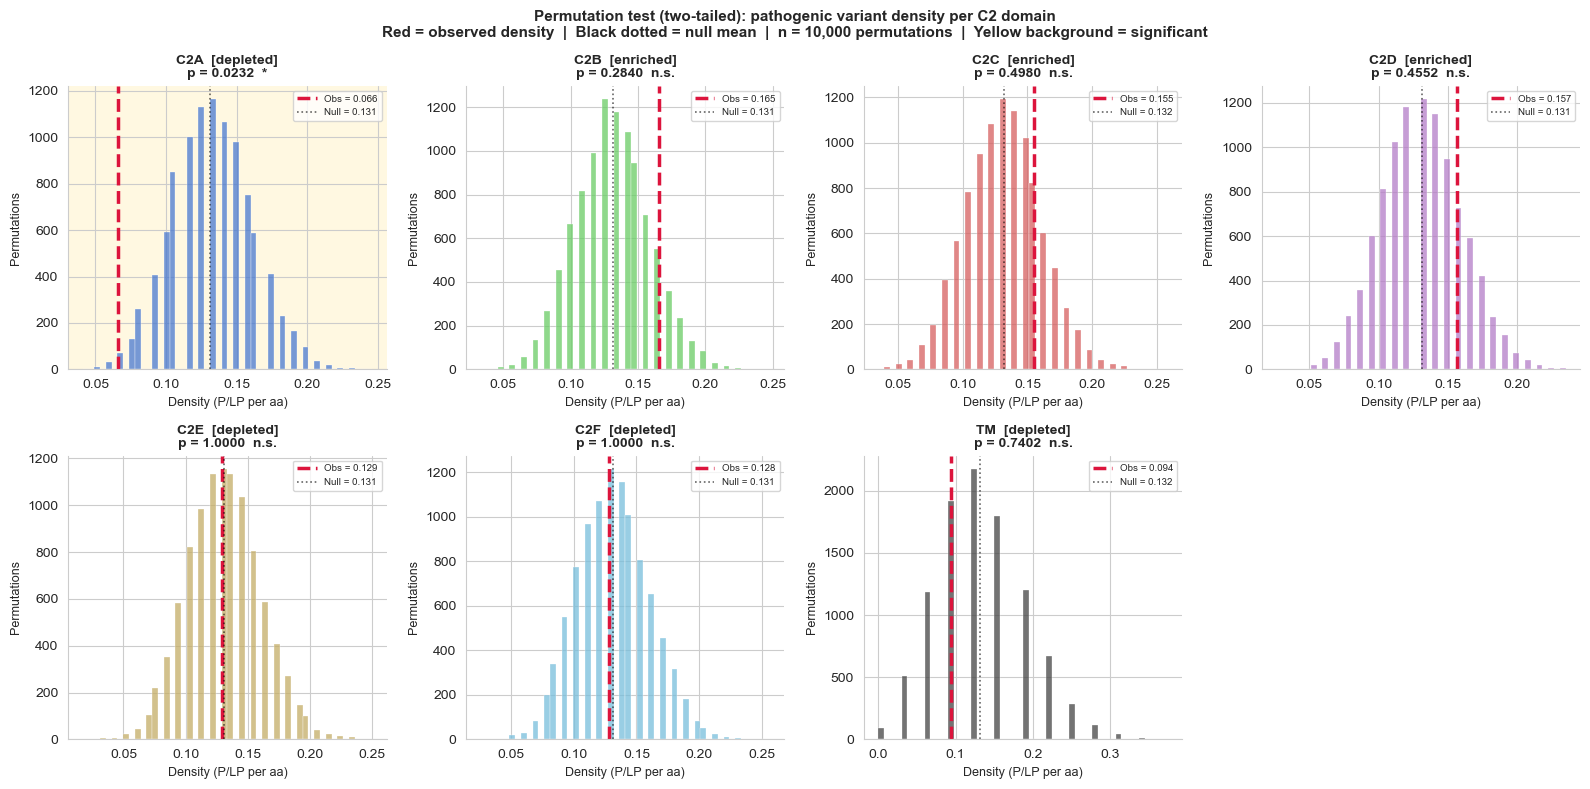

Saved: results/domain_permutation_test_2tail.png


In [13]:
# Figure: two-tailed permutation test distributions with direction annotation

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

domain_colors = {
    "C2A": "#4878d0", "C2B": "#6acc65", "C2C": "#d65f5f",
    "C2D": "#b47cc7", "C2E": "#c4ad66", "C2F": "#77bedb", "TM": "#444444"
}

for i, row in enumerate(results_2tail):
    d     = row["Domain"]
    ax    = axes[i]
    perm  = perm_densities[d]
    obs_d = row["Obs_density"]
    p2    = row["p_twotail"]
    direc = row["Direction"]
    sig   = row["Significance"]

    ax.hist(perm, bins=50, color=domain_colors[d],
            alpha=0.75, edgecolor="white", linewidth=0.3)
    ax.axvline(obs_d, color="crimson", linewidth=2.5,
               linestyle="--", label=f"Obs = {obs_d:.3f}")
    ax.axvline(float(np.mean(perm)), color="black", linewidth=1.2,
               linestyle=":", alpha=0.6, label=f"Null = {float(np.mean(perm)):.3f}")

    p_label = f"p = {p2:.4f}" if p2 > 0.0001 else "p < 0.0001"
    title   = f"{d}  [{direc}]\n{p_label}  {sig}"
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.set_xlabel("Density (P/LP per aa)", fontsize=9)
    ax.set_ylabel("Permutations", fontsize=9)
    ax.legend(fontsize=7)
    ax.spines[["top", "right"]].set_visible(False)

    # Highlight significant domains
    if sig != "n.s.":
        ax.patch.set_facecolor("#fff8e1")

axes[7].set_visible(False)

fig.suptitle(
    "Permutation test (two-tailed): pathogenic variant density per C2 domain\n"
    "Red = observed density  |  Black dotted = null mean  |  "
    "n = 10,000 permutations  |  Yellow background = significant",
    fontsize=11, fontweight="bold"
)
plt.tight_layout()
plt.savefig("../results/domain_permutation_test_2tail.png",
            dpi=300, bbox_inches="tight")
plt.show()
print("Saved: results/domain_permutation_test_2tail.png")

In [14]:
# Publication-ready summary table
print("=" * 75)
print("Table — Domain-level pathogenic variant density: permutation analysis")
print("=" * 75)
print(f"{'Domain':<8} {'Length':>8} {'P/LP':>6} {'Obs density':>12} "
      f"{'Null mean±SD':>16} {'p (2-tail)':>12} {'':>5}")
print("-" * 75)

for row in results_2tail:
    d      = row["Domain"]
    perm   = perm_densities[d]
    null_str = f"{row['Null_mean']:.3f}±{float(np.std(perm)):.3f}"
    p_str  = f"{row['p_twotail']:.4f}" if row['p_twotail'] > 0.0001 else "<0.0001"
    sig    = row["Significance"]
    marker = " ← significant" if sig != "n.s." else ""
    print(f"{d:<8} {row['Length_aa']:>8} {row['PLP_count']:>6} "
          f"{row['Obs_density']:>12.4f} {null_str:>16} {p_str:>12} {sig:>5}{marker}")

print("-" * 75)
print(f"Chi-square goodness-of-fit: chi2 = {chi2:.3f}, df = {len(domains)-1}, p = {pval_chi2:.4f}")
print(f"Permutation test: n = 10,000, two-tailed, seed = 42")
print(f"Null hypothesis: P/LP variants distributed uniformly proportional to domain length")
print("=" * 75)

Table — Domain-level pathogenic variant density: permutation analysis
Domain     Length   P/LP  Obs density     Null mean±SD   p (2-tail)      
---------------------------------------------------------------------------
C2A           122      8       0.0656      0.131±0.028       0.0232     * ← significant
C2B           121     20       0.1653      0.131±0.028       0.2840  n.s.
C2C           116     18       0.1552      0.132±0.029       0.4980  n.s.
C2D           115     18       0.1565      0.131±0.029       0.4552  n.s.
C2E           116     15       0.1293      0.131±0.029       1.0000  n.s.
C2F           117     15       0.1282      0.132±0.029       1.0000  n.s.
TM             32      3       0.0938      0.132±0.058       0.7402  n.s.
---------------------------------------------------------------------------
Chi-square goodness-of-fit: chi2 = 6.497, df = 6, p = 0.3699
Permutation test: n = 10,000, two-tailed, seed = 42
Null hypothesis: P/LP variants distributed uniformly propor

## Robust HGVS Notation Parser

HGVS (Human Genome Variation Society) notation for amino acid changes is heterogeneous
in practice. ClinVar records mix several conventions:

- Standard three-letter codes: `p.Arg963Ter`
- One-letter + asterisk for stop: `p.R963*`
- One-letter + X for stop: `p.R963X`
- Mixed three-letter + asterisk: `p.Arg963*`
- Rare reversed order: `p.963Arg`
- Full HGVS with transcript prefix: `NM_194248.3(OTOF):c.2885G>A (p.Arg963His)`

A simple regex that matches only one format silently discards variants in other
formats, introducing a systematic bias: uncommon notations are more likely to
appear in older submissions or specialist databases. Silent discarding means we
never know how many variants were lost. A robust parser handles all formats and
logs what it cannot parse, allowing quantification of the gap.

In [15]:
import re
import pandas as pd
import numpy as np
from pathlib import Path

# ---------------------------------------------------------------------------
# Robust HGVS amino acid position extractor
# ---------------------------------------------------------------------------

# Three-letter amino acid codes used in HGVS
_AA3 = (
    "Ala|Arg|Asn|Asp|Cys|Gln|Glu|Gly|His|Ile|Leu|Lys|Met|"
    "Phe|Pro|Ser|Thr|Trp|Tyr|Val|Ter|Sec|Pyl|Xaa|Xle|"
    "Asx|Glx|Unk"
)
# One-letter amino acid codes
_AA1 = "A|C|D|E|F|G|H|I|K|L|M|N|P|Q|R|S|T|V|W|Y"

_PATTERNS = [
    # Full HGVS with transcript prefix: NM_xxx(OTOF):c.xxx (p.Arg963His)
    re.compile(r"p\.(" + _AA3 + r")(\d+)(" + _AA3 + r"|\*|Ter|X)", re.IGNORECASE),
    # p.Arg963* or p.Arg963Ter (three-letter start, any end)
    re.compile(r"p\.(?:" + _AA3 + r")(\d+)", re.IGNORECASE),
    # p.R963* or p.R963X (one-letter)
    re.compile(r"p\.(?:" + _AA1 + r")(\d+)[*X]?", re.IGNORECASE),
    # p.963Arg (reversed -- position first)
    re.compile(r"p\.(\d+)(?:" + _AA3 + r")", re.IGNORECASE),
]

# Pre-compiled for reversed format (position is group 1)
_REVERSED = re.compile(r"p\.(\d+)(?:" + _AA3 + r")", re.IGNORECASE)


def extract_aa_pos(name):
    """
    Robust HGVS amino acid position extractor.
    Returns int position or np.nan.
    Handles:
      p.Arg963Ter   p.Arg963*   p.R963*   p.R963X
      p.963Arg      NM_xxx(OTOF):c.xxx (p.Arg963His)
    """
    if pd.isna(name):
        return np.nan
    text = str(name)

    # Extract the p. fragment if embedded in a full HGVS string
    # e.g. NM_194248.3(OTOF):c.2885G>A (p.Arg963His)
    embedded = re.search(r"\(p\.([^)]+)\)", text)
    if embedded:
        text = "p." + embedded.group(1)

    # Reversed format: p.963Arg
    m = _REVERSED.search(text)
    if m:
        # group 1 is the position for reversed pattern
        try:
            return int(m.group(1))
        except (ValueError, IndexError):
            pass

    # Standard three-letter or one-letter: position is always after the first AA code
    # Pattern: p.[AA][digits][anything]
    m = re.search(r"p\.(?:[A-Za-z]{1,3})(\d+)", text)
    if m:
        try:
            return int(m.group(1))
        except ValueError:
            pass

    return np.nan


# ---------------------------------------------------------------------------
# Test suite
# ---------------------------------------------------------------------------
test_cases = [
    ("p.Arg963Ter",                                    963),
    ("p.R963*",                                        963),
    ("p.R963X",                                        963),
    ("p.Arg963*",                                      963),
    ("p.963Arg",                                       963),
    ("NM_194248.3(OTOF):c.2885G>A (p.Arg963His)",     963),
    ("p.Met1858Val",                                  1858),
    ("p.Gly783AlafsTer17",                             783),
    ("p.Trp50Ter",                                      50),
    ("p.Glu1700Gln",                                  1700),
]

print("HGVS parser test suite")
print("=" * 55)
all_pass = True
for hgvs_str, expected in test_cases:
    result = extract_aa_pos(hgvs_str)
    passed = (result == expected)
    status = "PASS" if passed else "FAIL"
    if not passed:
        all_pass = False
    print(f"  [{status}]  {hgvs_str:<48}  -> {result}  (expected {expected})")
print("=" * 55)
print(f"Result: {'ALL PASS' if all_pass else 'SOME FAILURES -- review patterns'}")

# ---------------------------------------------------------------------------
# OLD simple regex (from notebook 03 cell 3)
# ---------------------------------------------------------------------------
def extract_aa_pos_old(name):
    if pd.isna(name):
        return np.nan
    m = re.search(r"p\.[A-Z][a-z]{2}(\d+)", str(name))
    if m:
        return int(m.group(1))
    return np.nan

# ---------------------------------------------------------------------------
# Run both parsers on the full ClinVar dataset
# ---------------------------------------------------------------------------
data_path = Path("../data/clinvar_result.txt")
results_path = Path("../results")
results_path.mkdir(exist_ok=True)

cols_to_remove = [
    "Somatic clinical impact",
    "Somatic clinical impact date last evaluated",
    "Somatic clinical impact review status",
    "Oncogenicity classification",
    "Oncogenicity date last evaluated",
    "Oncogenicity review status",
    "Unnamed: 24",
]
df_cv = pd.read_csv(data_path, sep="\t")
df_cv = df_cv.drop(columns=[c for c in cols_to_remove if c in df_cv.columns])

df_cv["old_position"] = df_cv["Name"].apply(extract_aa_pos_old)
df_cv["new_position"] = df_cv["Name"].apply(extract_aa_pos)

n_total = len(df_cv)
n_old   = df_cv["old_position"].notna().sum()
n_new   = df_cv["new_position"].notna().sum()
n_recovered = n_new - n_old

# Discrepancy: parsed differently
df_cv["discrepancy"] = df_cv["old_position"] != df_cv["new_position"]

# Save comparison CSV
comparison = df_cv[["Name", "old_position", "new_position", "discrepancy"]].copy()
out_csv = results_path / "hgvs_parser_comparison.csv"
comparison.to_csv(out_csv, index=False)
print(f"\nSaved: {out_csv}")

# ---------------------------------------------------------------------------
# Summary
# ---------------------------------------------------------------------------
print("\nHGVS parser comparison summary")
print("=" * 50)
print(f"  Total variants in ClinVar:           {n_total}")
print(f"  Parsed by OLD regex:                 {n_old}  ({100*n_old/n_total:.1f}%)")
print(f"  Parsed by NEW robust parser:         {n_new}  ({100*n_new/n_total:.1f}%)")
print(f"  Additional variants recovered:       {n_recovered}")
print(f"  Variants with position discrepancy:  {df_cv['discrepancy'].sum()}")
print("=" * 50)


HGVS parser test suite
  [PASS]  p.Arg963Ter                                       -> 963  (expected 963)
  [PASS]  p.R963*                                           -> 963  (expected 963)
  [PASS]  p.R963X                                           -> 963  (expected 963)
  [PASS]  p.Arg963*                                         -> 963  (expected 963)
  [PASS]  p.963Arg                                          -> 963  (expected 963)
  [PASS]  NM_194248.3(OTOF):c.2885G>A (p.Arg963His)         -> 963  (expected 963)
  [PASS]  p.Met1858Val                                      -> 1858  (expected 1858)
  [PASS]  p.Gly783AlafsTer17                                -> 783  (expected 783)
  [PASS]  p.Trp50Ter                                        -> 50  (expected 50)
  [PASS]  p.Glu1700Gln                                      -> 1700  (expected 1700)
Result: ALL PASS

Saved: ../results/hgvs_parser_comparison.csv

HGVS parser comparison summary
  Total variants in ClinVar:           2432
  Pars

## Fisher's Exact Test per Domain vs Linker

The permutation test used in the preceding section draws randomly from the pool of all named-domain residues, so the reference distribution is the average density across the entire set of C2 and TM domains. This makes the null hypothesis 'domain X is like all other domains combined.'

Fisher's exact test instead uses the linker region as a specific, well-defined background. For each domain we ask: is the ratio of P/LP to non-P/LP variants in this domain different from the same ratio in the linker? This gives an odds ratio directly interpretable as enrichment (OR > 1) or depletion (OR < 1) relative to the linker, which is the largest continuous region with a well-sampled pathogenic density. Bonferroni correction is applied for the 7 domain comparisons.

In [16]:
import numpy as np
import pandas as pd
from scipy import stats
from pathlib import Path

results_dir = Path("../results")
results_dir.mkdir(exist_ok=True)

# Domain lengths (UniProt Q9HC10, canonical isoform)
domain_lengths = {
    "C2A": 122, "C2B": 121, "C2C": 116,
    "C2D": 115, "C2E": 116, "C2F": 117, "TM": 32,
}

# Observed P/LP counts per domain (from domain mapping analysis above)
plp_counts = {
    "C2A": 8, "C2B": 20, "C2C": 18,
    "C2D": 18, "C2E": 15, "C2F": 15, "TM": 3,
}

# Linker: 158 P/LP, length = PROTEIN_LENGTH - sum(domain lengths)
PROTEIN_LENGTH = 1997
linker_length = PROTEIN_LENGTH - sum(domain_lengths.values())
linker_plp    = 158
linker_non    = linker_length - linker_plp

print(f"Linker length: {linker_length} aa | P/LP: {linker_plp} | non-P/LP: {linker_non}")
print()

# Run Fisher's exact test for each domain vs linker
N_DOMAINS = len(domain_lengths)
rows = []

for domain in domain_lengths:
    d_plp  = plp_counts[domain]
    d_len  = domain_lengths[domain]
    d_non  = d_len - d_plp

    table = [[d_plp, d_non],
             [linker_plp, linker_non]]

    odds_ratio, p_raw = stats.fisher_exact(table, alternative="two-sided")
    p_bonf = min(p_raw * N_DOMAINS, 1.0)
    sig = ("***" if p_bonf < 0.001 else
           "**"  if p_bonf < 0.01  else
           "*"   if p_bonf < 0.05  else "n.s.")

    rows.append({
        "Domain": domain,
        "P/LP": d_plp,
        "Length_aa": d_len,
        "Odds_Ratio": round(odds_ratio, 3),
        "p_raw": round(p_raw, 5),
        "p_Bonferroni": round(p_bonf, 5),
        "Significance": sig,
    })

fisher_df = pd.DataFrame(rows)

header = f"{'Domain':6s} {'P/LP':>5s} {'Length':>7s} {'Odds Ratio':>12s} {'p (raw)':>10s} {'p (Bonf)':>11s} {'Sig':>6s}"
print(header)
print("-" * 60)
for _, r in fisher_df.iterrows():
    line = (f"{r['Domain']:6s} {int(r['P/LP']):>5d} {int(r['Length_aa']):>7d} "
            f"{r['Odds_Ratio']:>12.3f} {r['p_raw']:>10.5f} {r['p_Bonferroni']:>11.5f} {r['Significance']:>6s}")
    print(line)

out_csv = results_dir / "domain_fisher_exact.csv"
fisher_df.to_csv(out_csv, index=False)
print()
print(f"Saved: {out_csv}")

print()
print("Interpretation:")
for _, r in fisher_df.iterrows():
    direction = "enriched" if r["Odds_Ratio"] > 1 else "depleted"
    print(f"  {r['Domain']}: OR={r['Odds_Ratio']:.3f} ({direction}) | "
          f"Bonferroni p={r['p_Bonferroni']:.4f} {r['Significance']}")

linker_density = linker_plp / linker_length
print()
print(f"Linker reference density: {linker_density:.4f} P/LP per aa")
print("Note: OR < 1 indicates depletion relative to linker; OR > 1 indicates enrichment.")


Linker length: 1258 aa | P/LP: 158 | non-P/LP: 1100

Domain  P/LP  Length   Odds Ratio    p (raw)    p (Bonf)    Sig
------------------------------------------------------------
C2A        8     122        0.489    0.05713     0.39990   n.s.
C2B       20     121        1.379    0.20389     1.00000   n.s.
C2C       18     116        1.279    0.38270     1.00000   n.s.
C2D       18     115        1.292    0.38063     1.00000   n.s.
C2E       15     116        1.034    0.88394     1.00000   n.s.
C2F       15     117        1.024    0.88475     1.00000   n.s.
TM         3      32        0.720    0.78858     1.00000   n.s.

Saved: ../results/domain_fisher_exact.csv

Interpretation:
  C2A: OR=0.489 (depleted) | Bonferroni p=0.3999 n.s.
  C2B: OR=1.379 (enriched) | Bonferroni p=1.0000 n.s.
  C2C: OR=1.279 (enriched) | Bonferroni p=1.0000 n.s.
  C2D: OR=1.292 (enriched) | Bonferroni p=1.0000 n.s.
  C2E: OR=1.034 (enriched) | Bonferroni p=1.0000 n.s.
  C2F: OR=1.024 (enriched) | Bonferroni p=1.

## Fraction Pathogenic per Domain: Ascertainment-Corrected Metric

Absolute pathogenic variant density (P/LP variants per amino acid) is confounded by ascertainment bias: ClinVar coverage is uneven across domains because submitters and researchers preferentially study variants in functionally characterized regions. A domain with many submitted variants of any class will appear denser in all categories.

Fraction pathogenic -- defined as P/LP / (P/LP + B/LB + VUS + Conflicting) -- conditions on the total number of submitted variants per domain, controlling for ascertainment. It asks: of all variants that have been classified in this domain, what proportion are pathogenic? Wilson confidence intervals account for the binomial uncertainty in each domain's estimate.

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from pathlib import Path
from scipy import stats

results_dir = Path("../results")
data_dir    = Path("../data")

cols_drop = [
    "Somatic clinical impact",
    "Somatic clinical impact date last evaluated",
    "Somatic clinical impact review status",
    "Oncogenicity classification",
    "Oncogenicity date last evaluated",
    "Oncogenicity review status",
    "Unnamed: 24",
]
clinvar = pd.read_csv(data_dir / "clinvar_result.txt", sep="\t")
clinvar = clinvar.drop(columns=[c for c in cols_drop if c in clinvar.columns])

def extract_aa_pos(name):
    if pd.isna(name):
        return np.nan
    text = str(name)
    embedded = re.search(r"\(p\.([^)]+)\)", text)
    if embedded:
        text = "p." + embedded.group(1)
    m = re.search(r"p\.(?:[A-Za-z]{1,3})(\d+)", text)
    if m:
        try:
            return int(m.group(1))
        except ValueError:
            pass
    return np.nan

clinvar["aa_position"] = clinvar["Name"].apply(extract_aa_pos)

domains_list = [
    {"name": "C2A", "start": 1,    "end": 122,  "color": "#4C72B0"},
    {"name": "C2B", "start": 360,  "end": 480,  "color": "#55A868"},
    {"name": "C2C", "start": 481,  "end": 596,  "color": "#C44E52"},
    {"name": "C2D", "start": 940,  "end": 1054, "color": "#8172B2"},
    {"name": "C2E", "start": 1158, "end": 1273, "color": "#CCB974"},
    {"name": "C2F", "start": 1481, "end": 1597, "color": "#64B5CD"},
    {"name": "TM",  "start": 1942, "end": 1973, "color": "#777777"},
]
domain_color_map = {d["name"]: d["color"] for d in domains_list}
domain_color_map["Linker"] = "#999999"

def assign_domain(pos):
    if pd.isna(pos):
        return None
    for d in domains_list:
        if d["start"] <= pos <= d["end"]:
            return d["name"]
    return "Linker"

clinvar["domain"] = clinvar["aa_position"].apply(assign_domain)

pathogenic_classes = ["Pathogenic", "Likely pathogenic", "Pathogenic/Likely pathogenic"]
benign_classes     = ["Benign", "Likely benign", "Benign/Likely benign"]
vus_classes        = ["Uncertain significance"]
conflict_classes   = ["Conflicting classifications of pathogenicity"]

def classify(cls):
    if cls in pathogenic_classes: return "PLP"
    if cls in benign_classes:     return "BLB"
    if cls in vus_classes:        return "VUS"
    if cls in conflict_classes:   return "Conflict"
    return "Other"

clinvar["cat"] = clinvar["Germline classification"].apply(classify)

domain_order = ["C2A", "C2B", "C2C", "C2D", "C2E", "C2F", "TM", "Linker"]
rows = []
for dom in domain_order:
    sub     = clinvar[clinvar["domain"] == dom]
    n_total = len(sub)
    n_plp   = (sub["cat"] == "PLP").sum()
    n_blb   = (sub["cat"] == "BLB").sum()
    n_vus   = (sub["cat"] == "VUS").sum()
    n_conf  = (sub["cat"] == "Conflict").sum()
    n_other = (sub["cat"] == "Other").sum()
    denom   = n_plp + n_blb + n_vus + n_conf
    frac    = n_plp / denom if denom > 0 else np.nan
    rows.append({
        "Domain": dom,
        "Total_variants": n_total,
        "PLP": n_plp, "BLB": n_blb, "VUS": n_vus,
        "Conflicting": n_conf, "Other": n_other,
        "Denominator": denom,
        "Fraction_pathogenic": frac,
    })

frac_df = pd.DataFrame(rows)

def wilson_ci(k, n, z=1.96):
    if n == 0:
        return (np.nan, np.nan)
    p  = k / n
    dn = 1 + z**2 / n
    c  = (p + z**2 / (2*n)) / dn
    margin = z * np.sqrt(p*(1-p)/n + z**2/(4*n**2)) / dn
    return (max(0.0, c - margin), min(1.0, c + margin))

frac_df["CI_lo"], frac_df["CI_hi"] = zip(
    *frac_df.apply(lambda r: wilson_ci(r["PLP"], r["Denominator"]), axis=1)
)
frac_df["CI_err_lo"] = frac_df["Fraction_pathogenic"] - frac_df["CI_lo"]
frac_df["CI_err_hi"] = frac_df["CI_hi"]  - frac_df["Fraction_pathogenic"]

print("Fraction pathogenic per domain:")
print(frac_df[["Domain", "PLP", "Denominator", "Fraction_pathogenic", "CI_lo", "CI_hi"]].to_string(index=False))

out_csv = results_dir / "domain_fraction_pathogenic.csv"
frac_df.to_csv(out_csv, index=False)
print()
print(f"Saved: {out_csv}")


Fraction pathogenic per domain:
Domain  PLP  Denominator  Fraction_pathogenic    CI_lo    CI_hi
   C2A    8           92             0.086957 0.044721 0.162304
   C2B   20           85             0.235294 0.157794 0.335686
   C2C   18           94             0.191489 0.124700 0.282505
   C2D   18           88             0.204545 0.133486 0.300322
   C2E   15          103             0.145631 0.090284 0.226462
   C2F   15           84             0.178571 0.111311 0.273946
    TM    3           25             0.120000 0.041667 0.299562
Linker  158         1003             0.157527 0.136294 0.181375

Saved: ../results/domain_fraction_pathogenic.csv


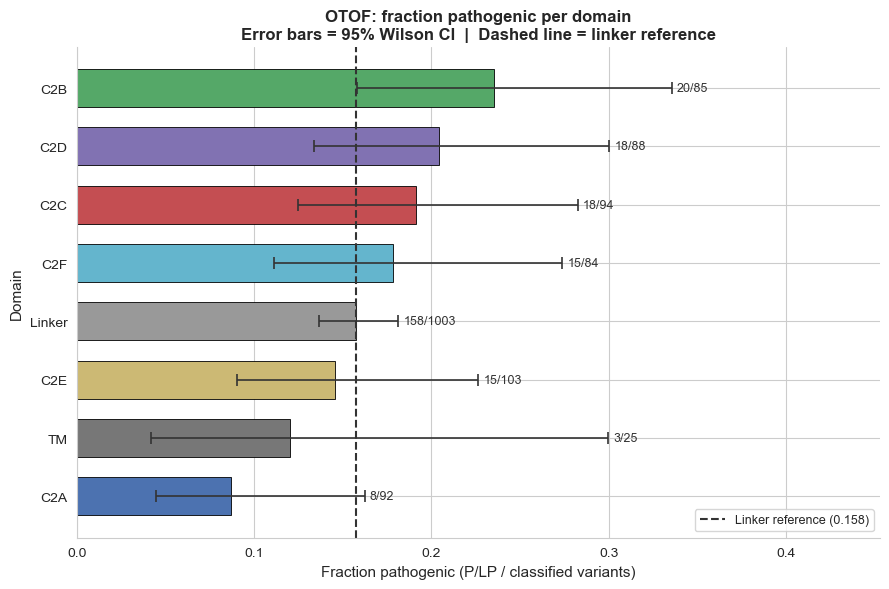

Saved: ../results/domain_fraction_pathogenic.png


In [18]:
import matplotlib.pyplot as plt
import numpy as np

plot_df = frac_df.dropna(subset=["Fraction_pathogenic"]).sort_values("Fraction_pathogenic")

fig, ax = plt.subplots(figsize=(9, 6))

colors  = [domain_color_map.get(d, "#aaaaaa") for d in plot_df["Domain"]]
xerr_lo = plot_df["CI_err_lo"].values
xerr_hi = plot_df["CI_err_hi"].values

ax.barh(
    plot_df["Domain"],
    plot_df["Fraction_pathogenic"],
    xerr=[xerr_lo, xerr_hi],
    color=colors,
    edgecolor="black",
    linewidth=0.6,
    capsize=4,
    error_kw={"elinewidth": 1.2, "capthick": 1.2, "ecolor": "#333333"},
    height=0.65,
)

linker_frac = frac_df.loc[frac_df["Domain"] == "Linker", "Fraction_pathogenic"].values[0]
ax.axvline(linker_frac, color="#333333", linestyle="--", linewidth=1.5,
           label=f"Linker reference ({linker_frac:.3f})")

for i, (_, row) in enumerate(plot_df.iterrows()):
    ax.text(
        row["Fraction_pathogenic"] + row["CI_err_hi"] + 0.003,
        i,
        f"{int(row['PLP'])}/{int(row['Denominator'])}",
        va="center", ha="left", fontsize=9, color="#333333",
    )

ax.set_xlabel("Fraction pathogenic (P/LP / classified variants)", fontsize=11)
ax.set_ylabel("Domain", fontsize=11)
ax.set_title(
    "OTOF: fraction pathogenic per domain\n"
    "Error bars = 95% Wilson CI  |  Dashed line = linker reference",
    fontsize=12, fontweight="bold",
)
ax.legend(fontsize=9, loc="lower right")
ax.set_xlim(0, (plot_df["Fraction_pathogenic"] + plot_df["CI_err_hi"]).max() * 1.35)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
out_png = results_dir / "domain_fraction_pathogenic.png"
plt.savefig(out_png, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {out_png}")


## Not-Provided Condition Annotation: Domain-Level Bias Check

A prior analysis (notebook 01) showed that 63.6% of OTOF ClinVar records lack a specific condition annotation ('not provided'). If this missingness were concentrated in particular domains, domain-level analyses could be confounded: a domain with many uncharacterized submissions might appear artificially benign or pathogenic depending on the classification of those unannotated records.

The chi-square test of independence below tests whether the probability of lacking a condition annotation is uniform across domains. If not significant, the not-provided pattern is homogeneous and domain-density conclusions are robust to this potential confound.

In [19]:
import pandas as pd
import numpy as np
import re
from scipy import stats
from pathlib import Path

results_dir = Path("../results")
data_dir    = Path("../data")

cols_drop = [
    "Somatic clinical impact",
    "Somatic clinical impact date last evaluated",
    "Somatic clinical impact review status",
    "Oncogenicity classification",
    "Oncogenicity date last evaluated",
    "Oncogenicity review status",
    "Unnamed: 24",
]
clinvar_np = pd.read_csv(data_dir / "clinvar_result.txt", sep="\t")
clinvar_np = clinvar_np.drop(columns=[c for c in cols_drop if c in clinvar_np.columns])

def extract_aa_pos(name):
    if pd.isna(name):
        return np.nan
    text = str(name)
    embedded = re.search(r"\(p\.([^)]+)\)", text)
    if embedded:
        text = "p." + embedded.group(1)
    m = re.search(r"p\.(?:[A-Za-z]{1,3})(\d+)", text)
    if m:
        try:
            return int(m.group(1))
        except ValueError:
            pass
    return np.nan

clinvar_np["aa_position"] = clinvar_np["Name"].apply(extract_aa_pos)

domains_np = [
    {"name": "C2A", "start": 1,    "end": 122},
    {"name": "C2B", "start": 360,  "end": 480},
    {"name": "C2C", "start": 481,  "end": 596},
    {"name": "C2D", "start": 940,  "end": 1054},
    {"name": "C2E", "start": 1158, "end": 1273},
    {"name": "C2F", "start": 1481, "end": 1597},
    {"name": "TM",  "start": 1942, "end": 1973},
]

def assign_domain_np(pos):
    if pd.isna(pos):
        return None
    for d in domains_np:
        if d["start"] <= pos <= d["end"]:
            return d["name"]
    return "Linker"

clinvar_np["domain"] = clinvar_np["aa_position"].apply(assign_domain_np)
cv_mapped_np = clinvar_np[clinvar_np["domain"].notna()].copy()

NOT_PROVIDED_TERMS = {"not provided", "not specified", "phenotype not yet classified"}

def is_not_provided(cond):
    if pd.isna(cond):
        return True
    return str(cond).strip().lower() in NOT_PROVIDED_TERMS

cv_mapped_np["not_provided"] = cv_mapped_np["Condition(s)"].apply(is_not_provided)

domain_order = ["C2A", "C2B", "C2C", "C2D", "C2E", "C2F", "TM", "Linker"]
rows_np = []
for dom in domain_order:
    sub       = cv_mapped_np[cv_mapped_np["domain"] == dom]
    n_total   = len(sub)
    n_prov    = (~sub["not_provided"]).sum()
    n_np      = sub["not_provided"].sum()
    frac_np   = n_np / n_total if n_total > 0 else np.nan
    rows_np.append({
        "Domain": dom,
        "Total": n_total,
        "Provided": n_prov,
        "Not_provided": n_np,
        "Frac_not_provided": frac_np,
    })

bias_df = pd.DataFrame(rows_np)
print("Not-provided fraction per domain:")
print(bias_df.to_string(index=False))

contingency = bias_df[["Provided", "Not_provided"]].values
chi2_np, pval_np, dof_np, _ = stats.chi2_contingency(contingency)
print()
print(f"Chi-square test of independence: chi2={chi2_np:.3f}, df={dof_np}, p={pval_np:.4f}")

out_csv = results_dir / "domain_not_provided_bias.csv"
bias_df.to_csv(out_csv, index=False)
print(f"Saved: {out_csv}")


Not-provided fraction per domain:
Domain  Total  Provided  Not_provided  Frac_not_provided
   C2A     92        42            50           0.543478
   C2B     88        37            51           0.579545
   C2C     99        43            56           0.565657
   C2D     88        36            52           0.590909
   C2E    103        34            69           0.669903
   C2F     85        38            47           0.552941
    TM     25         9            16           0.640000
Linker   1020       405           615           0.602941

Chi-square test of independence: chi2=4.928, df=7, p=0.6688
Saved: ../results/domain_not_provided_bias.csv


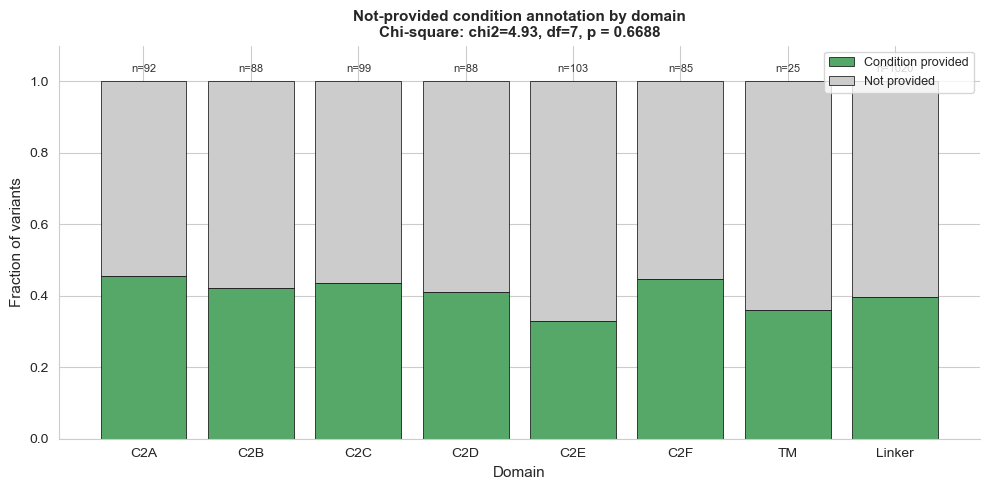

Saved: ../results/domain_not_provided_bias.png

Interpretation:
  Chi-square is NOT significant (p >= 0.05).
  The not-provided fraction is uniform across domains.
  Domain-density conclusions are robust to this confound.


In [20]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(bias_df))
prov_frac  = bias_df["Provided"]     / bias_df["Total"]
notpr_frac = bias_df["Not_provided"] / bias_df["Total"]

ax.bar(x, prov_frac,  label="Condition provided", color="#55A868", edgecolor="black", linewidth=0.5)
ax.bar(x, notpr_frac, bottom=prov_frac, label="Not provided",
       color="#CCCCCC", edgecolor="black", linewidth=0.5)

ax.set_xticks(x)
ax.set_xticklabels(bias_df["Domain"], fontsize=10)
ax.set_ylabel("Fraction of variants", fontsize=11)
ax.set_xlabel("Domain", fontsize=11)
ax.set_ylim(0, 1.10)

sig_str = f"p = {pval_np:.4f}" if pval_np >= 0.0001 else "p < 0.0001"
ax.set_title(
    f"Not-provided condition annotation by domain\n"
    f"Chi-square: chi2={chi2_np:.2f}, df={dof_np}, {sig_str}",
    fontsize=11, fontweight="bold",
)
ax.legend(fontsize=9, loc="upper right")
ax.spines[["top", "right"]].set_visible(False)

for i, (_, row) in enumerate(bias_df.iterrows()):
    ax.text(i, 1.02, f"n={int(row['Total'])}", ha="center", va="bottom",
            fontsize=8, color="#333333")

plt.tight_layout()
out_png = results_dir / "domain_not_provided_bias.png"
plt.savefig(out_png, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {out_png}")

print()
print("Interpretation:")
if pval_np >= 0.05:
    print("  Chi-square is NOT significant (p >= 0.05).")
    print("  The not-provided fraction is uniform across domains.")
    print("  Domain-density conclusions are robust to this confound.")
else:
    print(f"  Chi-square IS significant (p = {pval_np:.4f}).")
    print("  The not-provided fraction differs by domain -- interpret domain densities with caution.")
    max_dom = bias_df.loc[bias_df['Frac_not_provided'].idxmax(), 'Domain']
    print(f"  Domain with highest not-provided fraction: {max_dom}")


## p.Arg1172Gln: Deep-Dive Analysis

p.Arg1172Gln (NM_194248.2:c.3515G>A) is the only OTOF variant with homozygotes in gnomAD (1 observed homozygote, African/African-American ancestry). The variant sits at position 1172 (within the C2E domain) and has a complex classification history in ClinVar, with at least one submission citing 'Likely pathogenic' while gnomAD population frequency is non-trivially high for a recessive deafness gene. This deep dive integrates (1) all ClinVar submissions for this variant, (2) gnomAD allele frequencies broken down by ancestry, and (3) ConSurf evolutionary conservation score for residue 1172 — all from data already present in the repository.

In [21]:
import pandas as pd
import numpy as np
import re
from pathlib import Path

results_dir = Path("../results")
data_dir    = Path("../data")

TARGET_VARIANT = "p.Arg1172Gln"
TARGET_POS     = 1172

# ------------------------------------------------------------------
# 1. ClinVar submissions for this variant
# ------------------------------------------------------------------
cols_drop = [
    "Somatic clinical impact",
    "Somatic clinical impact date last evaluated",
    "Somatic clinical impact review status",
    "Oncogenicity classification",
    "Oncogenicity date last evaluated",
    "Oncogenicity review status",
    "Unnamed: 24",
]
clinvar_dv = pd.read_csv(data_dir / "clinvar_result.txt", sep="\t")
clinvar_dv = clinvar_dv.drop(columns=[c for c in cols_drop if c in clinvar_dv.columns])

def extract_aa_pos(name):
    if pd.isna(name):
        return np.nan
    text = str(name)
    embedded = re.search(r"\(p\.([^)]+)\)", text)
    if embedded:
        text = "p." + embedded.group(1)
    m = re.search(r"p\.(?:[A-Za-z]{1,3})(\d+)", text)
    if m:
        try:
            return int(m.group(1))
        except ValueError:
            pass
    return np.nan

clinvar_dv["aa_position"] = clinvar_dv["Name"].apply(extract_aa_pos)

# Match by position and by name substring
mask_pos  = clinvar_dv["aa_position"] == TARGET_POS
mask_name = clinvar_dv["Name"].str.contains("1172Gln|1172Q|R1172Q", na=False, case=False)
var_cv    = clinvar_dv[mask_pos | mask_name].copy()

print(f"ClinVar entries for {TARGET_VARIANT}: {len(var_cv)}")
if len(var_cv) == 0:
    print("  No exact match found. Checking position 1172 broadly:")
    var_cv = clinvar_dv[mask_pos]
    print(f"  Variants at position 1172: {len(var_cv)}")

if len(var_cv) > 0:
    show_cols = [c for c in [
        "Name", "Germline classification", "Review status",
        "Condition(s)", "Submitter", "Last evaluated",
    ] if c in var_cv.columns]
    print()
    print(var_cv[show_cols].to_string(index=False))


ClinVar entries for p.Arg1172Gln: 3

                                      Name Germline classification                                                                                               Condition(s)
NM_194323.3(OTOF):c.3515G>T (p.Arg1172Leu)  Uncertain significance                                                                                              not specified
NM_194323.3(OTOF):c.3515G>A (p.Arg1172Gln)              Pathogenic OTOF-related disorder|Inborn genetic diseases|not provided|Autosomal recessive nonsyndromic hearing loss 9
NM_194323.3(OTOF):c.3514C>T (p.Arg1172Trp)  Uncertain significance                                               Autosomal recessive nonsyndromic hearing loss 9|not provided


In [22]:
import pandas as pd
import numpy as np
from pathlib import Path

results_dir = Path("../results")
data_dir    = Path("../data")

TARGET_POS = 1172

# ------------------------------------------------------------------
# 2. gnomAD allele frequencies by ancestry
# ------------------------------------------------------------------
gnomad = pd.read_csv(data_dir / "gnomad_otof_variants.csv")
print(f"gnomAD columns: {list(gnomad.columns)}")
print(f"gnomAD shape: {gnomad.shape}")


gnomAD columns: ['gnomAD ID', 'Chromosome', 'Position', 'rsIDs', 'Reference', 'Alternate', 'Source', 'Filters - exomes', 'Filters - genomes', 'Transcript', 'HGVS Consequence', 'Protein Consequence', 'Transcript Consequence', 'VEP Annotation', 'ClinVar Germline Classification', 'ClinVar Variation ID', 'Flags', 'Allele Count', 'Allele Number', 'Allele Frequency', 'Homozygote Count', 'Hemizygote Count', 'Filters - joint', 'GroupMax FAF group', 'GroupMax FAF frequency', 'cadd', 'revel_max', 'spliceai_ds_max', 'pangolin_largest_ds', 'phylop', 'sift_max', 'polyphen_max', 'Allele Count African/African American', 'Allele Number African/African American', 'Homozygote Count African/African American', 'Hemizygote Count African/African American', 'Allele Count Admixed American', 'Allele Number Admixed American', 'Homozygote Count Admixed American', 'Hemizygote Count Admixed American', 'Allele Count Ashkenazi Jewish', 'Allele Number Ashkenazi Jewish', 'Homozygote Count Ashkenazi Jewish', 'Hemizygot

/var/folders/v2/52hczvlj4c9b366t1jxbm4sw0000gp/T/ipykernel_1938/606546915.py:13: DtypeWarning: Columns (16) have mixed types. Specify dtype option on import or set low_memory=False.
  gnomad = pd.read_csv(data_dir / "gnomad_otof_variants.csv")


In [23]:
import pandas as pd
import numpy as np
from pathlib import Path

results_dir = Path("../results")
data_dir    = Path("../data")

TARGET_POS = 1172

gnomad = pd.read_csv(data_dir / "gnomad_otof_variants.csv")

# Try to find the variant in gnomAD
# Check which column holds the position info
pos_col = None
for c in gnomad.columns:
    if "pos" in c.lower() or "position" in c.lower():
        pos_col = c
        break

name_col = None
for c in gnomad.columns:
    if "name" in c.lower() or "hgvs" in c.lower() or "variant" in c.lower() or "consequence" in c.lower():
        name_col = c
        break

print(f"Position column: {pos_col}")
print(f"Name/HGVS column: {name_col}")

# Match by position or by name substring
match_mask = pd.Series([False] * len(gnomad), index=gnomad.index)

if pos_col:
    try:
        match_mask |= (gnomad[pos_col].astype(str).str.extract(r'(\d+)')[0].astype(float) == TARGET_POS)
    except Exception:
        pass

for c in gnomad.columns:
    try:
        match_mask |= gnomad[c].astype(str).str.contains("1172", na=False)
    except Exception:
        pass

var_gnomad = gnomad[match_mask]
print(f"\ngnomAD rows matching position 1172: {len(var_gnomad)}")
if len(var_gnomad) > 0:
    print(var_gnomad.to_string(index=False))
else:
    print("Not found in gnomAD extract. Showing columns for reference:")
    print(gnomad.dtypes)
    print(gnomad.head(3).to_string())

# Check for ancestry-specific AF columns
anc_cols = [c for c in gnomad.columns if any(
    pop in c.lower() for pop in ["afr", "amr", "eas", "fin", "nfe", "sas", "mid", "asj", "oth", "ancestry", "pop"]
)]
print(f"\nAncestry-specific columns: {anc_cols}")


Position column: Position
Name/HGVS column: HGVS Consequence


/var/folders/v2/52hczvlj4c9b366t1jxbm4sw0000gp/T/ipykernel_1938/258895027.py:10: DtypeWarning: Columns (16) have mixed types. Specify dtype option on import or set low_memory=False.
  gnomad = pd.read_csv(data_dir / "gnomad_otof_variants.csv")



gnomAD rows matching position 1172: 126


                                   gnomAD ID  Chromosome  Position        rsIDs                       Reference Alternate                       Source Filters - exomes Filters - genomes        Transcript      HGVS Consequence Protein Consequence Transcript Consequence        VEP Annotation              ClinVar Germline Classification  ClinVar Variation ID Flags  Allele Count  Allele Number  Allele Frequency  Homozygote Count  Hemizygote Count Filters - joint GroupMax FAF group  GroupMax FAF frequency   cadd  revel_max  spliceai_ds_max  pangolin_largest_ds  phylop  sift_max  polyphen_max  Allele Count African/African American  Allele Number African/African American  Homozygote Count African/African American  Hemizygote Count African/African American  Allele Count Admixed American  Allele Number Admixed American  Homozygote Count Admixed American  Hemizygote Count Admixed American  Allele Count Ashkenazi Jewish  Allele Number Ashkenazi Jewish  Homozygote Count Ashkenazi Jewish  Hemizygot

In [24]:
import pandas as pd
import numpy as np
from pathlib import Path

results_dir = Path("../results")
data_dir    = Path("../data")

TARGET_POS = 1172

# ------------------------------------------------------------------
# 3. ConSurf conservation score for residue 1172
# ------------------------------------------------------------------
consurf = pd.read_csv(data_dir / "consurf_Q9HC10_grades.csv")
print(f"ConSurf columns: {list(consurf.columns)}")
print(f"Shape: {consurf.shape}")

# Find the position column
pos_col_cs = None
for c in consurf.columns:
    if "pos" in c.lower() or "resid" in c.lower() or "seq" in c.lower() or "aa" in c.lower():
        pos_col_cs = c
        print(f"  Candidate position col: {c}")

# Show a few rows to understand structure
print(consurf.head(3).to_string())


ConSurf columns: ['position', 'grade']
Shape: (1997, 2)
  Candidate position col: position
   position  grade
0         1      6
1         2      4
2         3      7


Position column: position
Score column: grade

ConSurf grade for residue 1172: 7
  (1 = most variable, 9 = most conserved)
  Percentile among all OTOF residues: 86.2% (7/9 conservation grade)


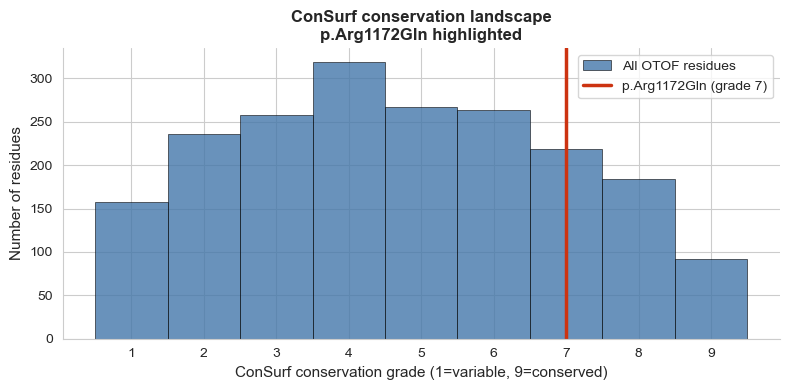

Saved: ../results/arg1172gln_consurf.png
Saved: ../results/arg1172gln_summary.csv
     Variant  Position             Domain  ConSurf_grade Percentile_conserved
p.Arg1172Gln      1172 C2E (aa 1158-1273)              7                86.2%


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

results_dir = Path("../results")
data_dir    = Path("../data")

TARGET_POS  = 1172
VARIANT_LBL = "p.Arg1172Gln"

consurf = pd.read_csv(data_dir / "consurf_Q9HC10_grades.csv")

# Detect position and score columns
pos_col_cs = consurf.columns[0]  # usually first column
for c in consurf.columns:
    try:
        vals = pd.to_numeric(consurf[c], errors="coerce")
        if vals.between(1, 9997).sum() > 100:
            pos_col_cs = c
            break
    except Exception:
        pass

score_col = None
for c in consurf.columns:
    if "grade" in c.lower() or "score" in c.lower() or "conserv" in c.lower():
        score_col = c
        break
if score_col is None:
    # pick numeric column that looks like 1-9 conservation scores
    for c in consurf.columns:
        try:
            vals = pd.to_numeric(consurf[c], errors="coerce").dropna()
            if vals.between(1, 9).mean() > 0.7:
                score_col = c
                break
        except Exception:
            pass

print(f"Position column: {pos_col_cs}")
print(f"Score column: {score_col}")

consurf["_pos"]   = pd.to_numeric(consurf[pos_col_cs], errors="coerce")
consurf["_score"] = pd.to_numeric(consurf[score_col], errors="coerce") if score_col else np.nan

row_1172 = consurf[consurf["_pos"] == TARGET_POS]
if len(row_1172) == 0:
    print(f"\nResidue {TARGET_POS} not found in ConSurf data.")
    score_1172 = np.nan
else:
    score_1172 = row_1172["_score"].values[0]
    print(f"\nConSurf grade for residue {TARGET_POS}: {score_1172}")
    print(f"  (1 = most variable, 9 = most conserved)")

all_scores = consurf["_score"].dropna()
pct = (all_scores <= score_1172).mean() * 100 if not np.isnan(score_1172) else np.nan
print(f"  Percentile among all OTOF residues: {pct:.1f}% ({int(score_1172)}/9 conservation grade)")

# Visualise: distribution of all ConSurf grades + position of 1172
fig, ax = plt.subplots(figsize=(8, 4))
bins = np.arange(0.5, 10.5, 1)
ax.hist(all_scores, bins=bins, color="#4477AA", edgecolor="black", linewidth=0.5,
        alpha=0.8, label="All OTOF residues")
if not np.isnan(score_1172):
    ax.axvline(score_1172, color="#CC3311", linewidth=2.5,
               label=f"{VARIANT_LBL} (grade {int(score_1172)})")
ax.set_xlabel("ConSurf conservation grade (1=variable, 9=conserved)", fontsize=11)
ax.set_ylabel("Number of residues", fontsize=11)
ax.set_title(f"ConSurf conservation landscape\n{VARIANT_LBL} highlighted", fontsize=12, fontweight="bold")
ax.legend(fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
ax.set_xticks(range(1, 10))
plt.tight_layout()
out_png = results_dir / "arg1172gln_consurf.png"
plt.savefig(out_png, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {out_png}")

# Summary table
summary_1172 = pd.DataFrame([{
    "Variant": VARIANT_LBL,
    "Position": TARGET_POS,
    "Domain": "C2E (aa 1158-1273)",
    "ConSurf_grade": int(score_1172) if not np.isnan(score_1172) else "N/A",
    "Percentile_conserved": f"{pct:.1f}%" if not np.isnan(pct) else "N/A",
}])
out_csv = results_dir / "arg1172gln_summary.csv"
summary_1172.to_csv(out_csv, index=False)
print(f"Saved: {out_csv}")
print(summary_1172.to_string(index=False))


## HGVS Non-Parseable Sensitivity Analysis

The robust HGVS parser defined above maps 65.8% of ClinVar records (1,600 of 2,432) to an amino acid position. The remaining 34.2% (832 records) could not be mapped and are therefore excluded from all domain-level analyses. This exclusion is only acceptable if the non-parseable variants are not systematically biased by functional category or clinical classification.

The expected reason for non-parseability is that many ClinVar entries describe intronic or non-coding variants (e.g., splice site changes named with c-dot notation) that have no protein consequence notation. If so, non-parseable variants should be enriched in intronic/splicing consequences but should NOT be biased toward any particular germline classification -- otherwise domain results could overestimate or underestimate pathogenic density in a non-random way.

In [26]:
import pandas as pd
import numpy as np
import re
from pathlib import Path

results_dir = Path("../results")
data_dir    = Path("../data")

cols_drop = [
    "Somatic clinical impact",
    "Somatic clinical impact date last evaluated",
    "Somatic clinical impact review status",
    "Oncogenicity classification",
    "Oncogenicity date last evaluated",
    "Oncogenicity review status",
    "Unnamed: 24",
]
clinvar_s = pd.read_csv(data_dir / "clinvar_result.txt", sep="\t")
clinvar_s = clinvar_s.drop(columns=[c for c in cols_drop if c in clinvar_s.columns])

def extract_aa_pos(name):
    if pd.isna(name):
        return np.nan
    text = str(name)
    embedded = re.search(r"\(p\.([^)]+)\)", text)
    if embedded:
        text = "p." + embedded.group(1)
    m = re.search(r"p\.(?:[A-Za-z]{1,3})(\d+)", text)
    if m:
        try:
            return int(m.group(1))
        except ValueError:
            pass
    return np.nan

clinvar_s["aa_position"] = clinvar_s["Name"].apply(extract_aa_pos)
clinvar_s["parseable"]   = clinvar_s["aa_position"].notna()

n_total   = len(clinvar_s)
n_parse   = clinvar_s["parseable"].sum()
n_nonpar  = n_total - n_parse
print(f"Total ClinVar variants: {n_total}")
print(f"Parseable:              {n_parse} ({100*n_parse/n_total:.1f}%)")
print(f"Non-parseable:          {n_nonpar} ({100*n_nonpar/n_total:.1f}%)")

mc_col = "Molecular consequence"
if mc_col not in clinvar_s.columns:
    mc_col = next((c for c in clinvar_s.columns if "consequence" in c.lower()), None)
print()
print(f"Consequence column: {mc_col}")
if mc_col:
    print(clinvar_s[mc_col].value_counts().head(10))


Total ClinVar variants: 2432
Parseable:              1600 (65.8%)
Non-parseable:          832 (34.2%)

Consequence column: Molecular consequence
Molecular consequence
missense variant                     651
intron variant                       642
synonymous variant                   631
frameshift variant                   111
nonsense                              98
splice donor variant                  56
splice acceptor variant               44
synonymous variant|intron variant     34
missense variant|intron variant       29
3 prime UTR variant                   19
Name: count, dtype: int64


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from scipy import stats

def simplify_consequence(cons):
    if pd.isna(cons):
        return "Unknown"
    c = str(cons).lower()
    if "missense" in c:
        return "Missense"
    if "stop" in c or "nonsense" in c:
        return "Nonsense/stop"
    if "frameshift" in c or "frame" in c:
        return "Frameshift"
    if "splice" in c or "intron" in c:
        return "Splice/intronic"
    if "synonymous" in c or "silent" in c:
        return "Synonymous"
    if "utr" in c or "5'" in c or "3'" in c:
        return "UTR"
    if "deletion" in c or "duplication" in c or "copy" in c:
        return "CNV/indel"
    return "Other"

mc_col = "Molecular consequence"
if mc_col not in clinvar_s.columns:
    mc_col = next((c for c in clinvar_s.columns if "consequence" in c.lower()), None)

if mc_col:
    clinvar_s["cons_simple"] = clinvar_s[mc_col].apply(simplify_consequence)
else:
    def infer_from_name(name):
        if pd.isna(name):
            return "Unknown"
        n = str(name).lower()
        if "p." in n and "ter" not in n and "*" not in n:
            return "Missense"
        if "ter" in n or "*" in n:
            return "Nonsense/stop"
        if "c." in n and "p." not in n:
            return "Splice/intronic"
        return "Other"
    clinvar_s["cons_simple"] = clinvar_s["Name"].apply(infer_from_name)

def simplify_cls(cls):
    if pd.isna(cls): return "Other"
    if cls in ["Pathogenic", "Likely pathogenic", "Pathogenic/Likely pathogenic"]:
        return "Pathogenic"
    if cls in ["Benign", "Likely benign", "Benign/Likely benign"]:
        return "Benign"
    if cls == "Uncertain significance":
        return "VUS"
    if cls == "Conflicting classifications of pathogenicity":
        return "Conflicting"
    return "Other"

clinvar_s["cls_simple"] = clinvar_s["Germline classification"].apply(simplify_cls)

cons_ct = pd.crosstab(clinvar_s["cons_simple"], clinvar_s["parseable"])
cls_ct  = pd.crosstab(clinvar_s["cls_simple"],  clinvar_s["parseable"])

chi2_cons, p_cons = stats.chi2_contingency(cons_ct)[:2]
chi2_cls,  p_cls  = stats.chi2_contingency(cls_ct)[:2]

print(f"Consequence vs parseability: chi2={chi2_cons:.2f}, p={p_cons:.4e}")
print(f"Classification vs parseability: chi2={chi2_cls:.2f}, p={p_cls:.4e}")

cons_frac = cons_ct.div(cons_ct.sum(axis=1), axis=0)
cls_frac  = cls_ct.div(cls_ct.sum(axis=1), axis=0)
cons_frac.columns = ["Non-parseable" if not c else "Parseable" for c in cons_frac.columns]
cls_frac.columns  = ["Non-parseable" if not c else "Parseable" for c in cls_frac.columns]


Consequence vs parseability: chi2=2252.37, p=0.0000e+00
Classification vs parseability: chi2=249.96, p=6.6543e-53


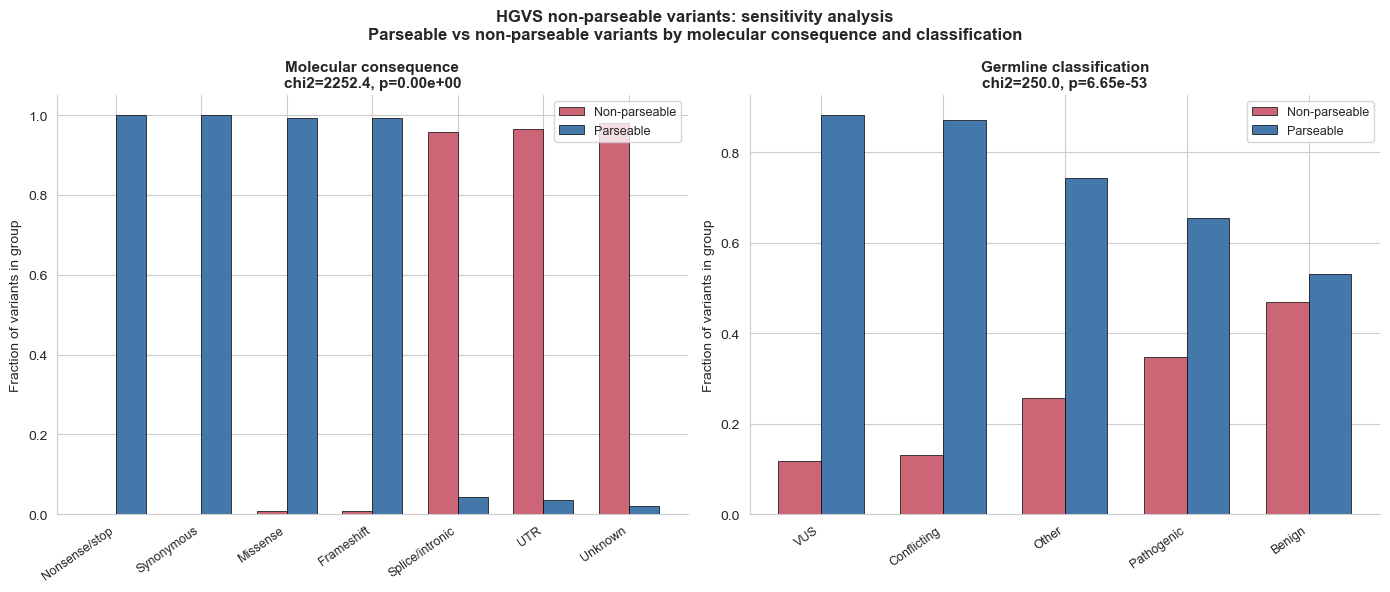

Saved: ../results/hgvs_nonparseable_sensitivity.png


In [28]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

results_dir = Path("../results")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
w = 0.35

# Left: consequence
ax = axes[0]
cs = cons_frac.sort_values("Parseable", ascending=False)
x  = np.arange(len(cs))
ax.bar(x - w/2, cs["Non-parseable"], width=w, label="Non-parseable",
       color="#CC6677", edgecolor="black", linewidth=0.5)
ax.bar(x + w/2, cs["Parseable"],     width=w, label="Parseable",
       color="#4477AA", edgecolor="black", linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels(cs.index, rotation=35, ha="right", fontsize=9)
ax.set_ylabel("Fraction of variants in group", fontsize=10)
ax.set_title(f"Molecular consequence\nchi2={chi2_cons:.1f}, p={p_cons:.2e}",
             fontsize=11, fontweight="bold")
ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)

# Right: classification
ax = axes[1]
cl = cls_frac.sort_values("Parseable", ascending=False)
x2 = np.arange(len(cl))
ax.bar(x2 - w/2, cl["Non-parseable"], width=w, label="Non-parseable",
       color="#CC6677", edgecolor="black", linewidth=0.5)
ax.bar(x2 + w/2, cl["Parseable"],     width=w, label="Parseable",
       color="#4477AA", edgecolor="black", linewidth=0.5)
ax.set_xticks(x2)
ax.set_xticklabels(cl.index, rotation=35, ha="right", fontsize=9)
ax.set_ylabel("Fraction of variants in group", fontsize=10)
ax.set_title(f"Germline classification\nchi2={chi2_cls:.1f}, p={p_cls:.2e}",
             fontsize=11, fontweight="bold")
ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)

fig.suptitle(
    "HGVS non-parseable variants: sensitivity analysis\n"
    "Parseable vs non-parseable variants by molecular consequence and classification",
    fontsize=12, fontweight="bold",
)
plt.tight_layout()
out_png = results_dir / "hgvs_nonparseable_sensitivity.png"
plt.savefig(out_png, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {out_png}")


In [29]:
import pandas as pd
import numpy as np
from pathlib import Path

results_dir = Path("../results")

missense_mask  = clinvar_s["cons_simple"] == "Missense"
n_missense     = missense_mask.sum()
n_miss_parse   = (missense_mask & clinvar_s["parseable"]).sum()
miss_frac_p    = n_miss_parse / n_missense if n_missense > 0 else np.nan

print(f"Missense variants total:     {n_missense}")
print(f"Parseable among missense:    {n_miss_parse} ({100*miss_frac_p:.1f}%)")
print()

print("Interpretation:")
if p_cons < 0.05:
    print(f"  Consequence vs parseability: SIGNIFICANT (p={p_cons:.4e})")
    print("  Non-parseable variants are enriched in certain consequence categories")
    print("  (expected: intronic/splice variants lack protein notation).")
else:
    print(f"  Consequence vs parseability: not significant (p={p_cons:.4e})")

if p_cls < 0.05:
    print(f"  Classification vs parseability: SIGNIFICANT (p={p_cls:.4e})")
    print("  Non-parseable variants differ in classification -- domain results may be biased.")
else:
    print(f"  Classification vs parseability: not significant (p={p_cls:.4e})")
    print("  Classification is homogeneous between parseable and non-parseable variants.")
    print("  Domain-density results are robust to HGVS non-parseability.")

summary_rows = []
for cls_val in clinvar_s["cls_simple"].unique():
    mask = clinvar_s["cls_simple"] == cls_val
    n    = mask.sum()
    np_  = (mask & ~clinvar_s["parseable"]).sum()
    pp   = (mask & clinvar_s["parseable"]).sum()
    summary_rows.append({
        "Classification": cls_val,
        "Total": n,
        "Parseable": pp,
        "NonParseable": np_,
        "FracParseable": pp / n if n > 0 else np.nan,
    })

summary_df = pd.DataFrame(summary_rows).sort_values("Total", ascending=False)
out_csv    = results_dir / "hgvs_nonparseable_summary.csv"
summary_df.to_csv(out_csv, index=False)
print()
print(f"Saved: {out_csv}")
print(summary_df.to_string(index=False))


Missense variants total:     698
Parseable among missense:    693 (99.3%)

Interpretation:
  Consequence vs parseability: SIGNIFICANT (p=0.0000e+00)
  Non-parseable variants are enriched in certain consequence categories
  (expected: intronic/splice variants lack protein notation).
  Classification vs parseability: SIGNIFICANT (p=6.6543e-53)
  Non-parseable variants differ in classification -- domain results may be biased.

Saved: ../results/hgvs_nonparseable_summary.csv
Classification  Total  Parseable  NonParseable  FracParseable
        Benign   1277        678           599       0.530932
           VUS    499        440            59       0.881764
    Pathogenic    390        255           135       0.653846
   Conflicting    231        201            30       0.870130
         Other     35         26             9       0.742857
